# 02 - GARCH(1,1) Analysis: ETH/USD Conditional Volatility

Research notebook only. Fits `askgene_quant.volatility.garch` GARCH(1,1) on real ETH/USD returns, inspects the fitted parameters, conditional volatility path, and (critically) the standardized residual diagnostics that tell us whether the model actually removed the volatility clustering seen in notebook 01.

In [1]:
import sys
from pathlib import Path

QUANT_SRC = Path("../quant/src").resolve()
sys.path.insert(0, str(QUANT_SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from askgene_quant.config import DEFAULT_VOLATILITY_SETTINGS as settings
from askgene_quant.data.loader import load_market_data
from askgene_quant.data.quality import check_data_quality
from askgene_quant.data.returns import log_returns

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

ASSET = "ETH-USD"
ohlcv = load_market_data(ASSET, cache_dir=(QUANT_SRC.parent / "data_cache"))
report = check_data_quality(ohlcv)
print(f"{len(ohlcv)} daily candles, {ohlcv.index.min().date()} -> {ohlcv.index.max().date()}")
print("quality errors:", report.errors or "none")
print(f"quality warnings: {len(report.warnings)}")
for w in report.warnings:
    print(" -", w)

returns = log_returns(ohlcv["close"])
print(f"\n{len(returns)} daily log returns")


3788 daily candles, 2016-05-18 -> 2026-10-02
quality errors: none
quality warnings: 2
 - 2 missing date(s) in expected D calendar between 2016-05-18 and 2026-10-02
 - 1 day(s) with |log return| > 0.5: 2020-03-12

3787 daily log returns


## Fitting GARCH(1,1) on the configured window

Parameter estimation (MLE) and conditional-variance updating are deliberately separate in `askgene_quant.volatility.garch` - `fit_garch` only runs here, once, on a fitting window; a live pipeline (`models.pipeline.GarchVolatilityPipeline`) then only calls the closed-form recursion per new observation and refits on a schedule (see `docs/methodology.md`).

In [2]:
from askgene_quant.volatility.garch import GARCHModel, conditional_variance_path

fit_window = returns.iloc[-settings.garch_fitting_window:]
model = GARCHModel().fit(fit_window)
p = model.params
print(f"omega = {p.omega:.3e}")
print(f"alpha = {p.alpha:.4f}  (reaction to shocks)")
print(f"beta  = {p.beta:.4f}  (persistence of past variance)")
print(f"alpha + beta = {p.persistence:.4f}  (<1 required for stationarity)")
print(f"mu    = {p.mu:.3e}")
print(f"\nconverged: {model.diagnostics.converged}, "
      f"log-likelihood: {model.diagnostics.log_likelihood:.1f}, "
      f"AIC: {model.diagnostics.aic:.1f}")

omega = 4.497e-04
alpha = 0.0958  (reaction to shocks)
beta  = 0.5522  (persistence of past variance)
alpha + beta = 0.6479  (<1 required for stationarity)
mu    = 8.740e-04

converged: True, log-likelihood: -2008.7, AIC: 4025.3


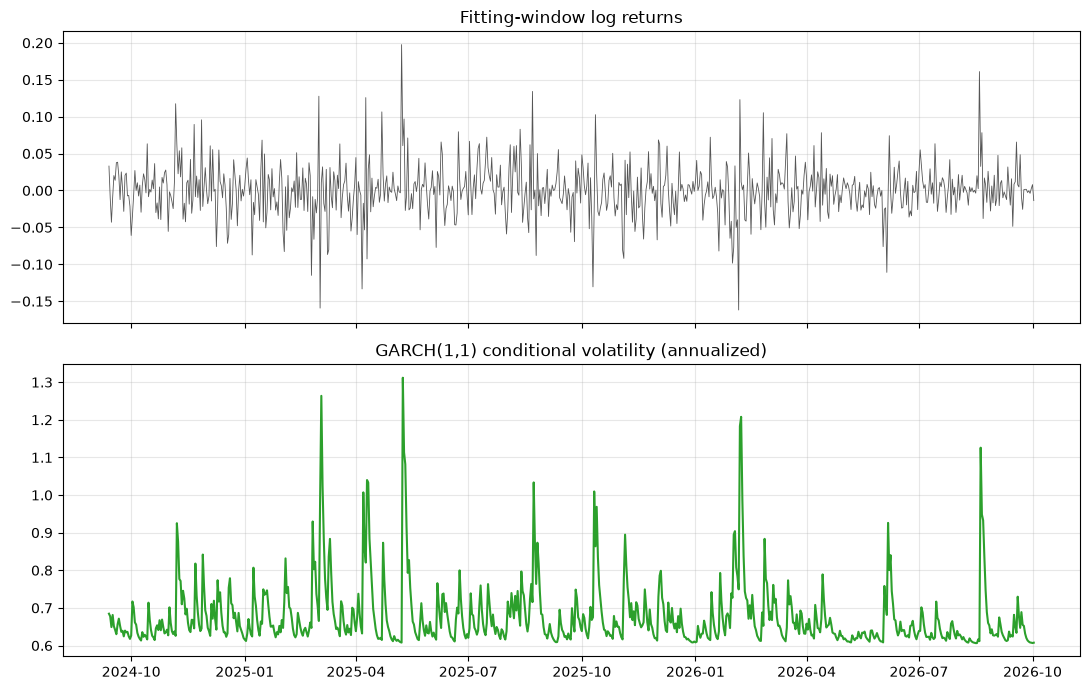

In [3]:
cond_var = conditional_variance_path(fit_window, p)
cond_vol_annualized = np.sqrt(cond_var * settings.periods_per_year)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(fit_window.index, fit_window, lw=0.6, color="#555")
axes[0].set_title("Fitting-window log returns")
axes[1].plot(cond_vol_annualized.index, cond_vol_annualized, color="#2ca02c")
axes[1].set_title("GARCH(1,1) conditional volatility (annualized)")
plt.tight_layout()
plt.show()

The conditional volatility should visibly spike right after large return shocks and then decay back toward the long-run level at a rate governed by `beta` - that's the whole point of a dynamic conditional-variance model versus a flat historical estimate.

## Standardized residual diagnostics

If the model is doing its job, the standardized residuals `z_t = (r_t - mu) / sigma_t` should look like i.i.d. noise with no leftover volatility clustering - i.e. the ACF of `z_t^2` should be near zero, unlike the ACF of the raw squared returns in notebook 01.

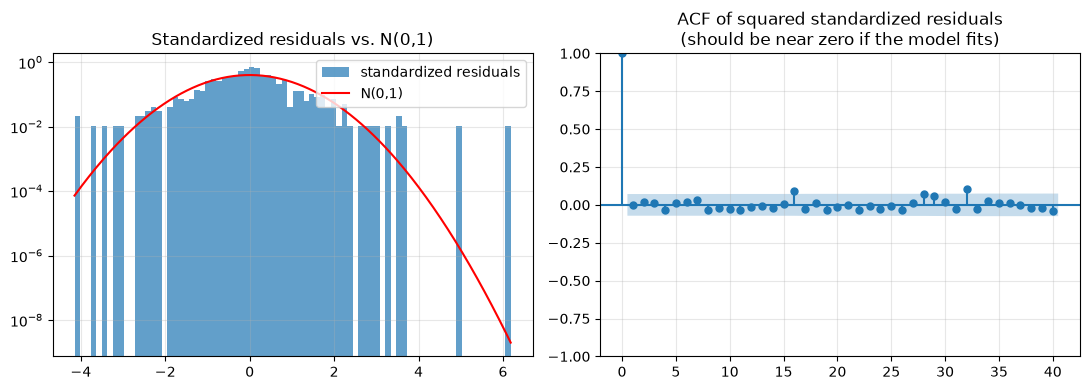

Ljung-Box test on squared standardized residuals (H0: no autocorrelation):
      lb_stat  lb_pvalue
10   3.835231   0.954474
20  13.653431   0.847624


In [4]:
std_resid = (fit_window - p.mu) / np.sqrt(cond_var)

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(std_resid, bins=80, density=True, alpha=0.7, label="standardized residuals")
x = np.linspace(std_resid.min(), std_resid.max(), 300)
from scipy import stats
axes[0].plot(x, stats.norm.pdf(x), "r-", lw=1.5, label="N(0,1)")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_title("Standardized residuals vs. N(0,1)")
plot_acf(std_resid**2, lags=40, ax=axes[1])
axes[1].set_title("ACF of squared standardized residuals\n(should be near zero if the model fits)")
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(std_resid**2, lags=[10, 20], return_df=True)
print("Ljung-Box test on squared standardized residuals (H0: no autocorrelation):")
print(lb)

A large Ljung-Box p-value (failing to reject H0) at the reported lags indicates the GARCH(1,1) model has absorbed most of the volatility clustering present in the raw squared returns. Standardized residuals still showing fatter-than-normal tails (if any remain) would motivate a Student-t error distribution in a future iteration - noted but out of scope for Phase C.

## One-step and multi-step forecasts from the current state

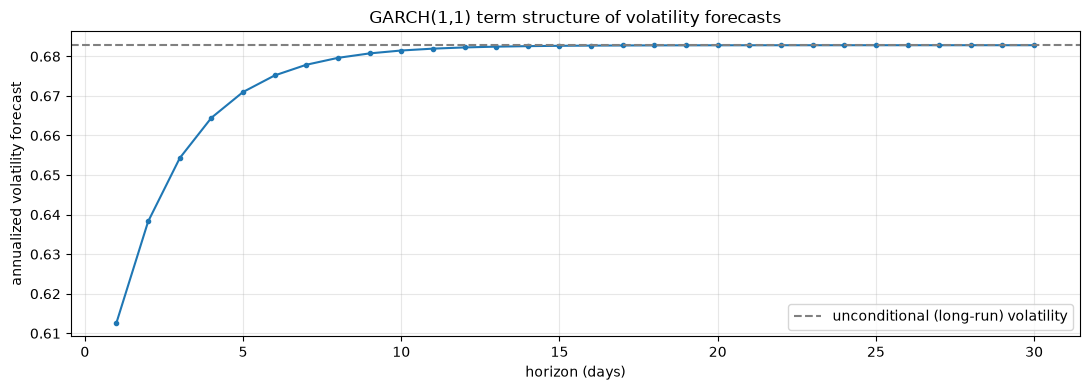

In [5]:
horizon = 30
forecast_var = model.forecast(horizon)
forecast_vol = np.sqrt(forecast_var * settings.periods_per_year)

fig, ax = plt.subplots()
ax.plot(range(1, horizon + 1), forecast_vol, marker="o", ms=3)
ax.axhline(np.sqrt(p.unconditional_variance * settings.periods_per_year) if p.persistence < 1 else np.nan,
           color="gray", ls="--", label="unconditional (long-run) volatility")
ax.set_xlabel("horizon (days)")
ax.set_ylabel("annualized volatility forecast")
ax.set_title("GARCH(1,1) term structure of volatility forecasts")
ax.legend()
plt.tight_layout()
plt.show()

Because `alpha + beta < 1`, the forecast mean-reverts toward the unconditional (long-run) variance as the horizon grows - exactly the qualitative behavior that distinguishes GARCH from EWMA (which has no mean reversion and forecasts a flat line at the current level for every horizon).